In [27]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

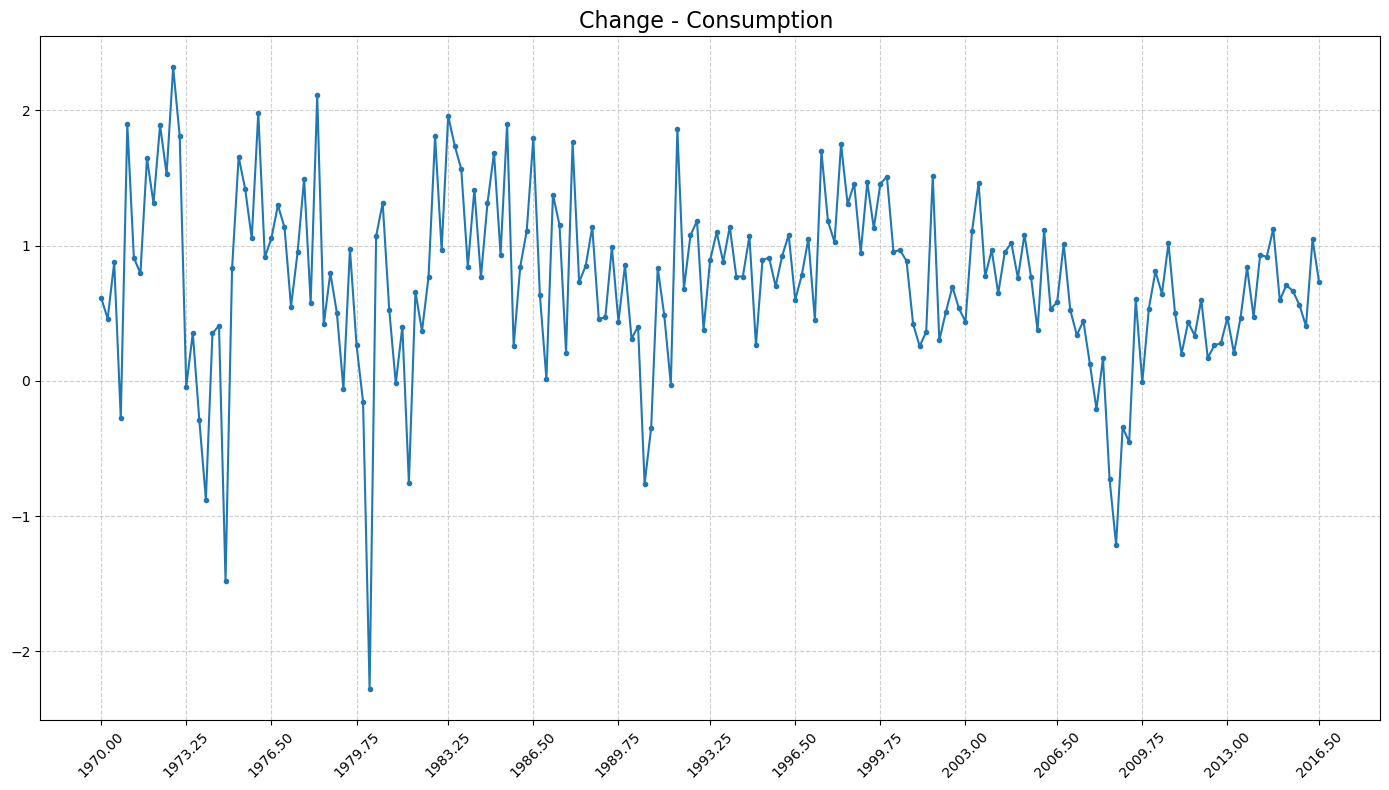

In [28]:
# 데이터 원본 Consumption 변화율
file_path ="C:/Users/배현우/Lap/R-sq/uschange.csv" 
df = pd.read_csv(file_path, index_col="Index")
plt.figure(figsize=(14, 8)) 
plt.plot(df.index, df['Consumption'], marker='.', linestyle='-')
plt.title('Change - Consumption ', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
n_ticks = 15
tick_indices = np.linspace(0, len(df.index) - 1, n_ticks, dtype=int)
plt.xticks(df.index[tick_indices], rotation=45)
plt.tight_layout() 

plt.show()

## prophet 모델을 통한 Consumption 예측
1) 예측 변수 Income , Production , Unemployment , Savings 으로 설정 
2) 종속 변수는 Consumption 으로 설정해서 Consumption에 대한 예측변수들의 상관계수를 계산
3) 모델은 Prophet의 기본모델을 사용함.
4) 실제값과 예측값을 비교하는 r_squared 값 계산
   

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_4212\3322096239.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df['ds'] = pd.date_range(start=start_date_actual, periods=num_periods, freq='Q')
20:33:33 - cmdstanpy - INFO - Chain [1] start processing
20:33:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet 모델
독립 변수: ['Income', 'Production', 'Unemployment', 'Savings']
R-제곱 (R²): 0.7694


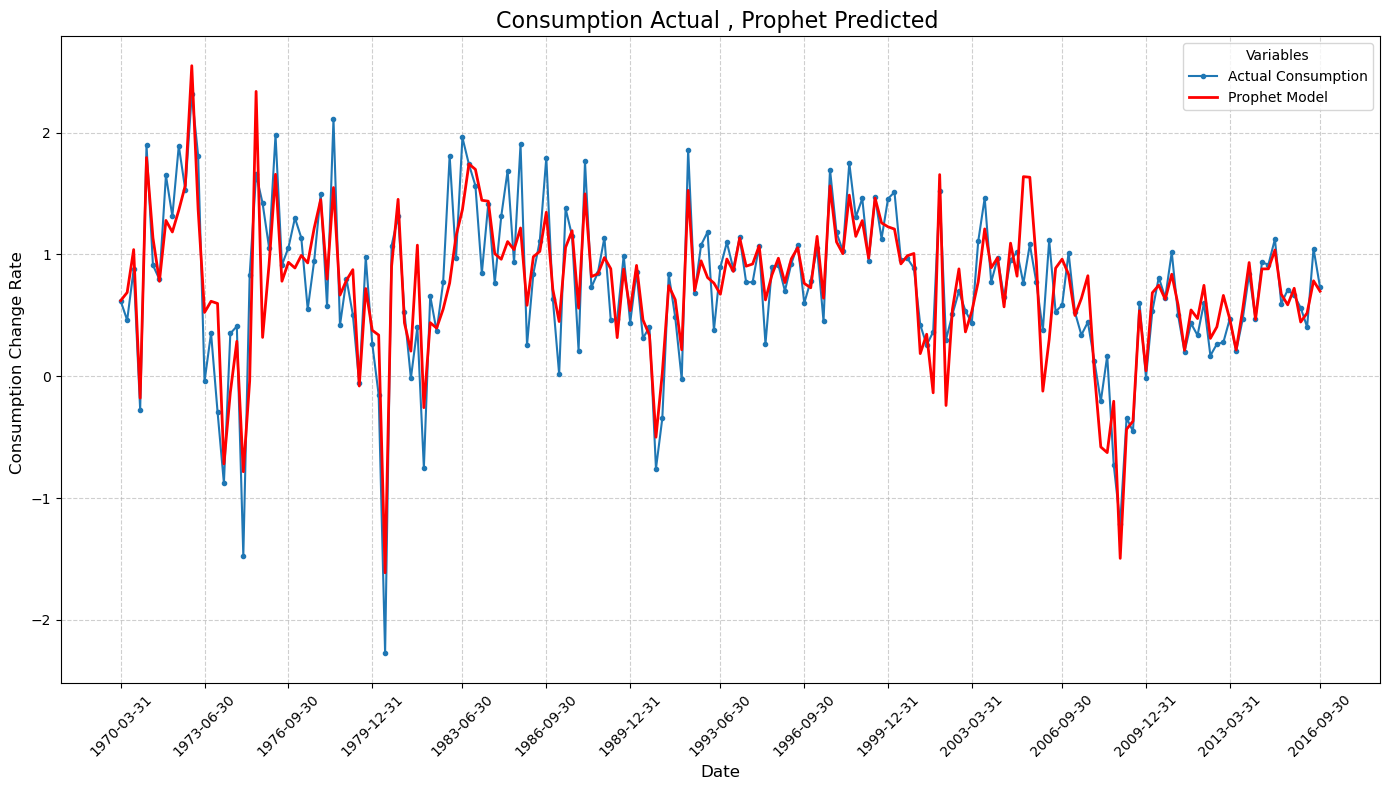

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

start_date_actual = '1970-03-31' 
num_periods = len(df) 
df['ds'] = pd.date_range(start=start_date_actual, periods=num_periods, freq='Q')
df['y'] = df['Consumption'].values

# Prophet 데이터프레임 및 회귀 변수 설정
regressors = ['Income', 'Production', 'Unemployment', 'Savings']
prophet_df = df[['ds', 'y'] + regressors].copy() 
model_prophet = Prophet()

# 독립 변수 (회귀 변수) 추가
for regressor in regressors:
    model_prophet.add_regressor(regressor)

# 모델 학습 및 예측
model_prophet.fit(prophet_df)
future = prophet_df[['ds'] + regressors].copy() 
forecast = model_prophet.predict(future)
y_predicted_prophet = forecast['yhat'].values 

# 평가 지표 계산
r_squared_prophet = r2_score(df['y'], y_predicted_prophet)

# 결과 출력
print("Prophet 모델")
print(f"독립 변수: {regressors}")
print(f"R-제곱 (R²): {r_squared_prophet:.4f}")

# 결과 플로팅
plt.figure(figsize=(14, 8))
plt.plot(df['ds'], df['y'], label='Actual Consumption', marker='.', linestyle='-')
plt.plot(df['ds'], y_predicted_prophet, label='Prophet Model', linestyle='-', color='red', linewidth=2)

plt.title(f'Consumption Actual , Prophet Predicted ', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Consumption Change Rate ', fontsize=12)
plt.legend(title='Variables')
plt.grid(True, linestyle='--', alpha=0.6)

n_ticks = 15
tick_indices = np.linspace(0, len(df['ds']) - 1, n_ticks, dtype=int)
plt.xticks(df['ds'].iloc[tick_indices], rotation=45) 
plt.tight_layout() 

plt.show()

## 선형회귀 모델을 통한 Consumption 예측
1) 예측 변수 Income , Production , Unemployment , Savings 으로 설정 
2) 종속 변수는 Consumption 으로 설정해서 Consumption에 대한 예측변수들의 상관계수를 계산
3) 모델은 선형회귀 LinearRegression() 모델로 설정하고 y와 x에대한 최적의 선형관계를 최소제곱법을 사용해서 구함
4) 실제값과 예측값을 비교하여 모델을 설명하는 R^2값을 계산함.





독립 변수: Income, Production, Unemployment, Savings
상관 계수: [ 0.71448464  0.04589098 -0.20476616 -0.04526925]
절편): 0.2673
R-제곱 (R²): 0.7540


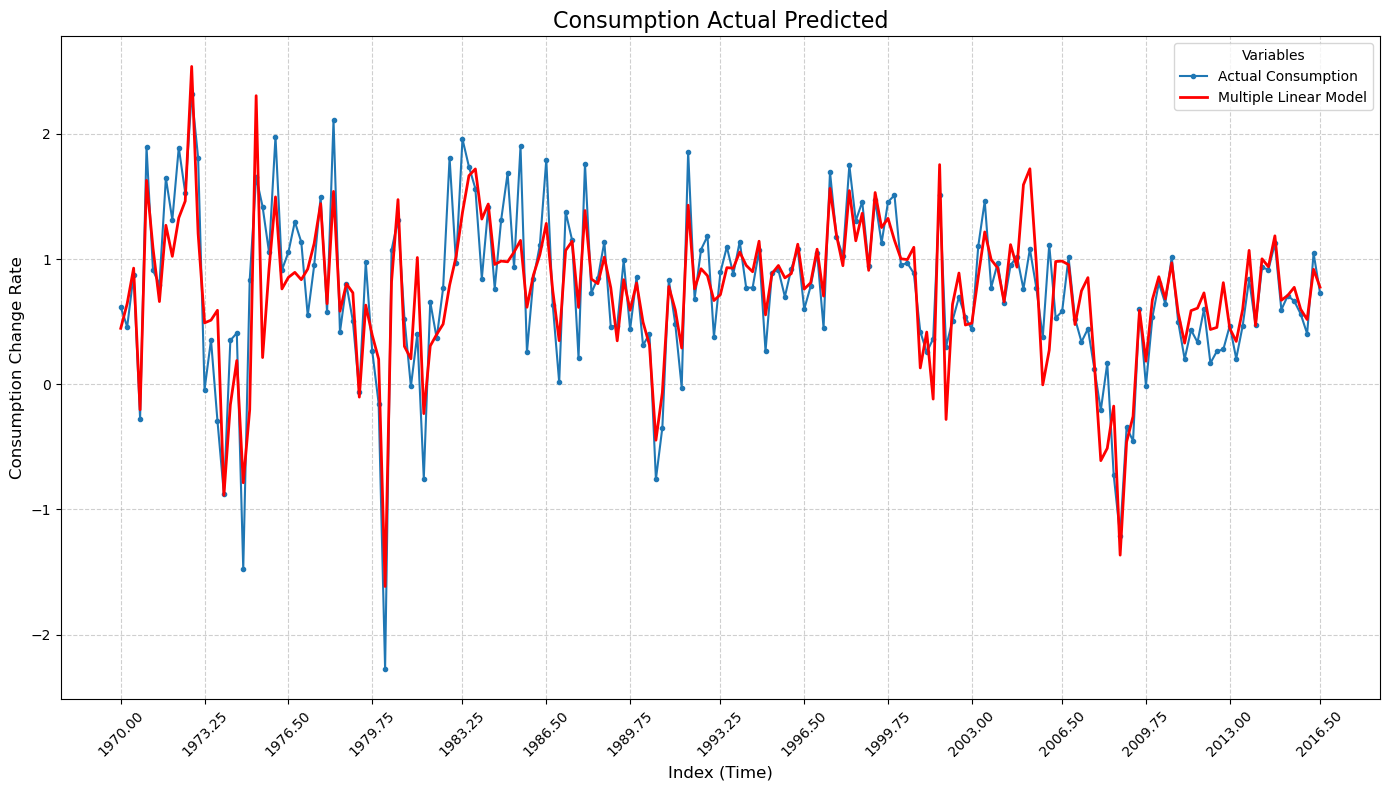

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv(file_path, index_col="Index")

X_multi = df[['Income', 'Production', 'Unemployment', 'Savings']].values
y = df['Consumption'].values 

# 선형 회귀 모델 학습
model_multi = LinearRegression()
model_multi.fit(X_multi, y)
# 예측값 계산
y_predicted_multi = model_multi.predict(X_multi) 
# R-제곱 (R²) 값 계산
r_squared_multi = r2_score(y, y_predicted_multi)

print(f"독립 변수: Income, Production, Unemployment, Savings")
print(f"상관 계수: {model_multi.coef_}")
print(f"절편): {model_multi.intercept_:.4f}")
print(f"R-제곱 (R²): {r_squared_multi:.4f}")

# 실제 Consumption 값 플롯팅
plt.figure(figsize=(14, 8))
plt.plot(df.index, y, label='Actual Consumption', marker='.', linestyle='-')

plt.plot(df.index, y_predicted_multi, label='Multiple Linear Model', linestyle='-', color='red', linewidth=2)

plt.title(f'Consumption Actual Predicted', fontsize=16)
plt.xlabel('Index (Time)', fontsize=12)
plt.ylabel('Consumption Change Rate', fontsize=12)
plt.legend(title='Variables')

# 그리드 및 레이아웃 조정
plt.grid(True, linestyle='--', alpha=0.6)
n_ticks = 15
tick_indices = np.linspace(0, len(df.index) - 1, n_ticks, dtype=int)
plt.xticks(df.index[tick_indices], rotation=45)
plt.tight_layout() 

plt.show()